# Feature Engineering
Testing the information content of reasonable features on model predictive capabilities

### Base features
Derived directly from statistics included in regular season detailed results
1. `points_scored_diff`
2. `points_allowed_diff`
3. `shots_made_diff` 
4. `shots_attempted_diff` 
5. `threes_made_diff`
6. `threes_attempted_diff` 
7. `free_throws_made_diff` 
8. `free_throws_attempted_diff`
9. `offensive_rebounds_diff` 
10. `defensive_rebounds_diff` 
11. `assists_diff`
12. `turnovers_diff` 
13. `steals_diff` 
14. `blocks_diff` 
15. `fouls_diff`
16. `win_pct_diff`
17. `fg_pct_diff`
18. `three_pct_diff`
19. `free_throw_pct_diff`
20. `seed_diff`

## Contents
1. [Colley Strength of Schedule Rating](#colley-strength-of-schedule-rating)
2. [Momentum Features](#momentum-features)
3. [Era Normalization](#era-normalization)
4. [Upset Rate](#upset-rate)

## Summary
This notebook provides empirical analysis of the predictive power of heuristic features for tournament prediction models like relative performance metrics in Colley rating, as well as time series analysis in momentum features and era normalization. We employ feature engineering techniques run under a consistent, leakage-safe methodology (train-only screening, redundancy checks, multivariate confirmation before conclusions) and analyze potential features using correlation with outcome and existing features, and performance on small feature logistic regression models. The results indicate that none of these proposed features provide significant additional information to a model.

### Import libraries

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
from src.utils.config import load_config
from src.data.colley import compute_colley_ratings
from src.data.dataset import parse_seed

## Colley Strength of Schedule Rating
The Colley matrix is a bias free algorithm for competition ratings that ranks sports teams using only game outcomes and completely ignores other typical ranking metrics like margin of victory, preseason bias, and historical reputation. 

There are generally two common automated rating algorithms based on interconnected schedules, the Colley matrix and the Massey matrix. 

### Massey Rating
The Massey system is based on the assumption that the difference in ratings between two teams should equal the expected margin of victory and uses least squares to minimize errors. We formulate the Massey problem as

$$
Xr = y
$$

where $r$ is the unknown vector of team ratings, $y$ is a vector of point differentials for each game k, and $X$ is an $m \times n$ matrix of $m$ games and $n$ teams. For each game $k$ with winning team $i$ and losing team $j$,

$$
X_{ki} = +1 \\
X_{kj} = -1 \\
X_{kc} = 0 \text{ for all other teams not involved in game } k
$$

Interpreting the construction of the system, we see that the ratings $r$ should exactly equal the point differential between two teams should they play in a game. Since $m > n$ for any given season, $X$ is a tall matrix and the above system most likely cannot be solved explicitly. We now formulate solving for the ratings $r$ as a least squares problem and construct the normal equations

$$
X^TXr=X^Ty
$$

and reinterpreting the normal equations gives the traditional Massey formulation

$$
Mr = p
$$

where $p$ becomes a vector where each element $p_i$ is the net point differential for team $i$ calculated as total points scored minus total points allowed across all games and $M$ is the $n \times n$ Massey matrix where n is the number of teams. The matrix is constructed as 
$$
M_{ii} = \text{total number of games team i has played} \\
M_{ij} = \text{negative number of times team i played team j} \\
\text{for } 0<i,j\leq n
$$
The system attempts to find the ratings $r$ such that the season per game sum a teams rating minus all of their opponents ratings is equal to that teams season point differential. By construction, all rows of the Massey matrix add to 0. As a result, the matrix is singular since multiplying by a vector of all ones will give the zero vector, meaning the kernel is non-zero and the matrix is not invertible. The canonical solution to this problem thus involves replacing the final row of $M$ with a row of ones and setting $p_n = 0$, forcing the sum of all rating to be zero and thus standardizing the Massey rating such that $r = 0$ represents the average performance, and the difference between two Massey ratings predicts the point spread of their matchup. This approach does not sacrifice information since the ratings are inherently relative and the rating for the final team lost to the replacement is still fully constrained by the information of all other teams. 

### Colley Rating
Due to the necessity of post hoc modification for the stability of the Massey rating, the inclusion of point differential as a current feature in the dataset, and the potential for blowouts to distort the predictive power of the Massey rating, we instead consider the Colley rating. The Colley system ignores the margin of victory and relies on Laplace's Rule of Succession to calculate a bias-free, self-consistent win percentage. The Colley rating fundamentally builds on Laplace's rule. Assuming every game is independent and has an equal chance of winning

$$
r_i = \frac{w_i + 1}{t_i + 2}
$$

where for team $i$, $r_i$ is the rating or win probability, $w_i$ is the total number of observed wins, and $t_i$ is the total number of observed games. However, not all wins in sports are equally likely as beating a good team should be much less likely than beating a bad team. To address this, we first recognize that we can rewrite the number of wins as

$$
w_i = \frac{w_i - l_i}{2} + \frac{w_i + l_i}{2} = \frac{w_i - l_i}{2} + \frac{t_i}{2}
$$

Then since $\frac{t_i}{2}$ inherently follows Laplace's assumption that all teams are average and thus give an equal win probability, we replace it with $\sum_{j \in Opp(i)} r_j$ the sum of the actual opponents ratings, since each represents the win probability against that opponent. Substituting back into the original formula gives

$$
r_i = \frac{1 + \frac{w_i - l_i}{2} + \sum_{j \in Opp(i)} r_j}{t_i + 2}
$$

rearranging the equation so that we can solve for all ratings simultaneously and defining $n_{ij}$ as the number of times team $i$ plays team $j$ to simplify the sum index we obtain

$$
(t_i + 2)r_i - \sum_{j \neq i} n_{ij}r_j = 1 + \frac{w_i - l_i}{2}
$$

which is a system of linear equations we can write in matrix form. We formulate the Colley problem as

$$
Cr = b
$$

where $r$ is the vector of unknown ratings, $b$ is a vector with each element $b_i$ is constructed as

$$
b_i = 1 + \frac{w_i - l_i}{2} \text{ where $w_i$ and $l_i$ are the wins and losses for team i}
$$

and C is the Colley matrix, constructed as

$$
C_{ii} = 2 + \text{ total number of games team i has played} \\
C_{ij} = \text{negative number of times team i played team j} \\
\text{for } 0<i,j\leq n
$$

Because of the $+2$ on the diagonal of the Colley matrix, $C$ is strictly diagonally dominant, so by the Levy–Desplanques Theorem it must be invertible and we can solve the system cleanly for $r$. Since $r_i$ is constructed based on Laplace's rule, it serves as an adjusted win probability, with the average rating across all teams being $0.5$.

Here we attempt to determine if the Colley rating has predictive power as a feature in our models or if it would be redundant with existing features and only add noise. We specifically test whether the regular season Colley rating correletes with the actual outcome of tournament games, what the AUC of the ROC for just the feature is for a basic logistic regression, and whether Colley rating is redundant with existing features.

For label correlation we use point-biserial correlation to map the continuous ratings to binary outcome labels

$$r_{pb} = \frac{M_1 - M_0}{s_n} \sqrt{\frac{n_1 n_0}{n^2}}$$

We use the canonical ROC AUC formulation

$$AUC = \int_{0}^{1} \text{TPR}(f) \, d\text{FPR}(f)$$

And we use standard Pearson correlation for existing features

$$ r _{xy}=\frac{\text{Cov}(x,y)}{\sqrt{\text{Var}(x)\cdot \text{Var}(y)}}$$

In [12]:
config = load_config()
team_stats = pd.read_csv(f"{config['data']['processed_dir']}/team_stats_baseline.csv")
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')
season_results = pd.read_csv('data/raw/MRegularSeasonDetailedResults.csv')
seeds = pd.read_csv('data/raw/MNCAATourneySeeds.csv')

train_start, train_end = config['data']['train_seasons']

colley_ratings = compute_colley_ratings(season_results)
team_stats = pd.merge(team_stats, colley_ratings, on=['season', 'team_id'], how='left')

seeds['seed'] = seeds['Seed'].apply(parse_seed)
seeds = seeds[['Season', 'TeamID', 'seed']]

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)
all_matchups = pd.merge(
    left=all_matchups, right=seeds,
    left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']
)
all_matchups = pd.merge(
    left=all_matchups, right=seeds,
    left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'],
    suffixes=(None, '_l')
)

all_matchups['colley_diff'] = all_matchups['colley'] - all_matchups['colley_l']
all_matchups['win_pct_diff'] = all_matchups['win_pct'] - all_matchups['win_pct_l']
all_matchups['seed_diff'] = all_matchups['seed'] - all_matchups['seed_l']

matchups = all_matchups[['colley_diff', 'win_pct_diff', 'seed_diff']].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[['colley_diff', 'win_pct_diff', 'seed_diff']] = -mirrored[['colley_diff', 'win_pct_diff', 'seed_diff']]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

colley_corr, _ = pointbiserialr(matchups['label'], matchups['colley_diff'])

lr = LogisticRegression()
lr.fit(screen_train[['colley_diff']], screen_train['label'])
colley_probs = lr.predict_proba(screen_val[['colley_diff']])[:, 1]
colley_auc = roc_auc_score(screen_val['label'], colley_probs)

redundancy_win_pct = matchups['colley_diff'].corr(matchups['win_pct_diff'])
redundancy_seed = matchups['colley_diff'].corr(matchups['seed_diff'])

print(f'colley_diff correlation with label: {colley_corr:.4f}')
print(f'colley_diff single-feature AUC: {colley_auc:.4f}')
print(f'colley_diff redundancy with win_pct_diff: {redundancy_win_pct:.4f}')
print(f'colley_diff redundancy with seed_diff: {redundancy_seed:.4f}')

colley_diff correlation with label: 0.4680
colley_diff single-feature AUC: 0.7568
colley_diff redundancy with win_pct_diff: 0.7579
colley_diff redundancy with seed_diff: -0.9355


We also run a logistic regression using just seeds to predict outcome and seed plus Colley using both features to predict outcome and compare the AUC ROC for both since pure accuracy metrics rely on arbitrary cutoffs for prediction.

In [13]:
seed_only = LogisticRegression()
seed_only.fit(screen_train[['seed_diff']], screen_train['label'])
seed_only_auc = roc_auc_score(screen_val['label'], seed_only.predict_proba(screen_val[['seed_diff']])[:, 1])

seed_colley = LogisticRegression()
seed_colley.fit(screen_train[['seed_diff', 'colley_diff']], screen_train['label'])
seed_colley_auc = roc_auc_score(screen_val['label'], seed_colley.predict_proba(screen_val[['seed_diff', 'colley_diff']])[:, 1])

print(f'seed_diff alone: {seed_only_auc:.4f}')
print(f'seed_diff + colley_diff: {seed_colley_auc:.4f}')

seed_diff alone: 0.7655
seed_diff + colley_diff: 0.7653


We find that the colley feature correlates reasonably well with the outcomes and provides significantly better than random AUC, but ultimately it is substantially redundant with existing features. An $\approx .75$ correlation with win percentage and $\approx .93$ (sign is a result of lower seed = better) with seed suggests that the feature itself provides minimal new information. Comparing the seed alone lr with the two feature lr suggests that adding Colley is potentially adding noise for the model to overfit or misinterpret rather than adding predictive power. 

## Momentum Features
Heuristically, momentum based features follow conventional logic that successful teams are the teams that 'get hot at the right time' or are having outlier years. To rigorously develop a feature that measures current performance vs previous years results, we start by defining a baseline. For each year, we exclude the current years performance to prevent target leakage and then calculate the trailing average of a given statistic over the past $w$ seasons. For a given team's output in a stat $x$ at season $t$, we calculate this average as

$$\bar{x}_{t-1}^{(w)} = \frac{1}{k} \sum_{i=1}^{k} x_{t-i}$$

where $k = \min(w, t-1)$ to account for limited history (ie start of the observation period) and $x_{t-i}$ is the value of the statistic from $i$ seasons ago. We then define 'momentum' as the arithmetic difference between a team's current season performance vs their historical baseline to determine when a programis over or under performing relative to thier recent years. The momentum $m_t$ for the current season $t$ is then

$$m_t = x_t - \bar{x}_{t-1}^{(w)}$$

allowing our feature to track the current stats divergence from the historical 'center of gravity' and detect outlier years.

We now attempt to evaluate the potential for momentum based features to improve the predictive power of our models. We formulate momentum using a trailing average and define the feature as the difference in momentum for a stat in a matchup. We choose $w=5$ since college basketball is heuristically more reasonable since college rosters turn over completely every 4-5 years but shorter windows might be too noisy.

We evaluate again using biserial-point correlation with the outcome labels, AUC ROC for logistic regression on just the momentum feature, and Pearson correleation with the baseline statistic.

In [14]:
config = load_config()
team_stats = pd.read_csv(f"{config['data']['processed_dir']}/team_stats_baseline.csv")
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')

train_start, train_end = config['data']['train_seasons']
window = 5

stat_cols = ['points_scored', 'points_allowed', 'shots_made', 'shots_attempted', 'threes_made',
             'threes_attempted', 'free_throws_made', 'free_throws_attempted', 'offensive_rebounds',
             'defensive_rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'fouls',
             'win_pct', 'fg_pct', 'three_pct', 'free_throw_pct']

team_stats = team_stats.sort_values(['team_id', 'season'])

# exclude the current season so momentum never leaks this season's outcome into its own trend feature
for stat in stat_cols:
    trailing_avg = team_stats.groupby('team_id')[stat].transform(
        lambda s: s.shift(1).rolling(window=window, min_periods=1).mean()
    )
    team_stats[f'{stat}_momentum'] = (team_stats[stat] - trailing_avg).fillna(0)

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)

momentum_cols = [f'{stat}_momentum' for stat in stat_cols]
for stat in stat_cols + momentum_cols:
    all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']

diff_cols = [f'{stat}_diff' for stat in stat_cols]
momentum_diff_cols = [f'{stat}_diff' for stat in momentum_cols]

matchups = all_matchups[diff_cols + momentum_diff_cols].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[diff_cols + momentum_diff_cols] = -mirrored[diff_cols + momentum_diff_cols]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

results = []
for stat in stat_cols:
    base_col = f'{stat}_diff'
    mom_col = f'{stat}_momentum_diff'

    corr, _ = pointbiserialr(matchups['label'], matchups[mom_col])

    lr = LogisticRegression()
    lr.fit(screen_train[[mom_col]], screen_train['label'])
    mom_probs = lr.predict_proba(screen_val[[mom_col]])[:, 1]
    mom_auc = roc_auc_score(screen_val['label'], mom_probs)

    redundancy = matchups[base_col].corr(matchups[mom_col])

    results.append({
        'stat': stat,
        'momentum_corr': corr,
        'momentum_auc': mom_auc,
        'redundancy_with_base': redundancy
    })

screen_df = pd.DataFrame(results).sort_values('momentum_auc', ascending=False)
screen_df

/var/folders/x8/pjxggchn73v63mqy7c5tz60r0000gn/T/ipykernel_32936/2032435996.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']


,stat,momentum_corr,momentum_auc,redundancy_with_base
14,fouls,-0.034469,0.556781,0.590719
7,free_throws_attempted,-0.068228,0.553398,0.613830
6,free_throws_made,-0.065052,0.550521,0.624538
9,defensive_rebounds,-0.049780,0.550492,0.604080
15,win_pct,-0.023909,0.546155,0.360989
12,steals,0.048101,0.542382,0.660974
1,points_allowed,-0.044120,0.521447,0.565250
5,threes_attempted,0.029397,0.516662,0.639962
11,turnovers,-0.061884,0.516402,0.585971
8,offensive_rebounds,0.040210,0.500889,0.567444


We also examine the per season trends in both the base stats and the momentum formulation. We plot the average value of the difference between winner performance and loser performance in each stat. We expect the stat differences to sit consistently above zero for stats where higher scores are good (ie steals) and below zero for the inverse. On the same plot we also graph the same average value of the difference for the momentum of that stat. If momentum is a meaningful predictor, we would expect the momentum line to stay away from the zero line, meaning the winning team is actually trending upwards relative to their past seasons performances.

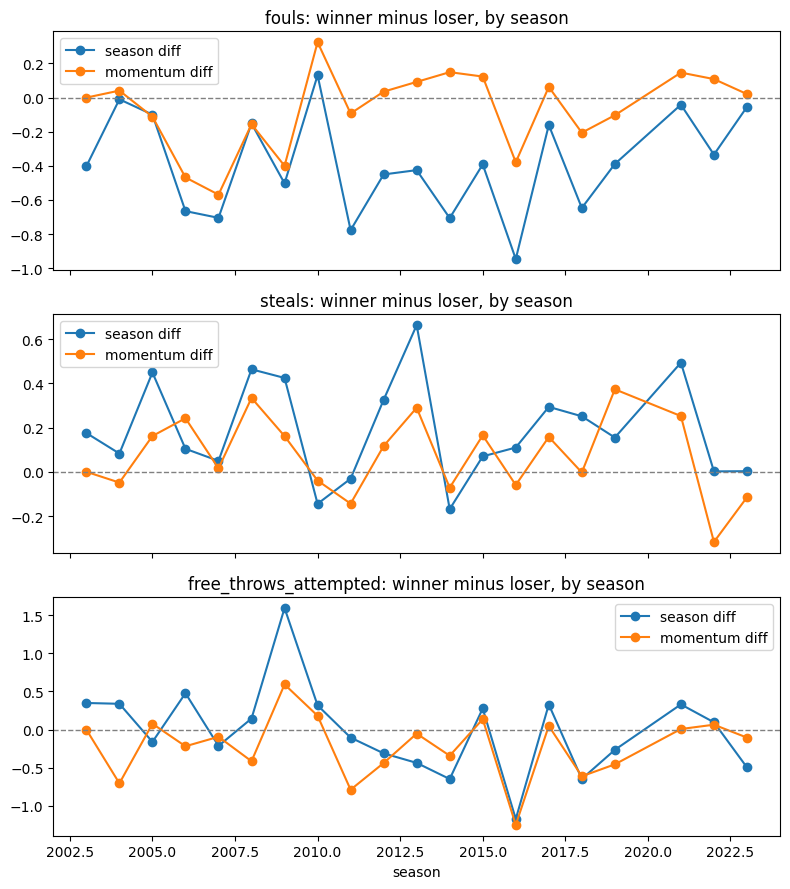

In [15]:
key_stats = ['fouls', 'steals', 'free_throws_attempted']

season_trend = all_matchups.groupby('Season')[[f'{s}_diff' for s in key_stats]].mean()
season_trend_momentum = all_matchups.groupby('Season')[[f'{s}_momentum_diff' for s in key_stats]].mean()

fig, axes = plt.subplots(len(key_stats), 1, figsize=(8, 3 * len(key_stats)), sharex=True)
for ax, stat in zip(axes, key_stats):
    ax.plot(season_trend.index, season_trend[f'{stat}_diff'], marker='o', label='season diff')
    ax.plot(season_trend_momentum.index, season_trend_momentum[f'{stat}_momentum_diff'], marker='o', label='momentum diff')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{stat}: winner minus loser, by season')
    ax.legend()

axes[-1].set_xlabel('season')
plt.tight_layout()
plt.show()

While the momentum features show relatively low correlation with the base stat they are tracking, we find that even the highest AUC momentum features barely exceeds the $.50$ random threshold, meaning using any momentum feature to predict winners is within noise of random selection. The near zero and often negative correlation coefficients with the true labels provide further evidence against these features. Looking at the plots for the highest AUC momentum features confirms these findings as the baseline statistics are relatively well-behaved but the momentum hovers noisily around zero.

## Era Normalization
Instead of looking at temporal trends, we experiment with cross-sectional standardization. We normalize every stat into a z score relative to the leagues distribution in that season to compute era adjusted statistics. This seeks to minimize the effects of league wide drift on inference, for example preventing a model from seeing lower three point shooting teams winning in earlier years and predicting losses for high three point shooting teams in recent years when three point shooting across the league has exploded. We calculate z-scores on each stat first 

$$z_{i,t} = \frac{x_{i,t} - \mu_t}{\sigma_t}$$

and then diff the z-scores between teams for the true feature.

$$\Delta z_t = z_{W,t} - z_{L,t}$$
$$\Delta z_t = \frac{x_{W,t} - \mu_t}{\sigma_t} - \frac{x_{L,t} - \mu_t}{\sigma_t}$$
$$\Delta z_t = \frac{x_{W,t} - x_{L,t}}{\sigma_t}$$
$$\Delta z_t = \frac{\Delta x_t}{\sigma_t}$$

 The resulting statistic is the difference in the original stat scaled by the inverse of the standard deviation of the stat in that era, or the volatility scaling of the original feature. We thus expect an extremely high correlation with the original feature. This retains the intended effect of scaling stat differences relative to the league wide distribution, making the AUC and correlation metrics still valuable evaluations.

In [16]:
config = load_config()
team_stats = pd.read_csv(f"{config['data']['processed_dir']}/team_stats_baseline.csv")
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')

train_start, train_end = config['data']['train_seasons']

stat_cols = ['points_scored', 'points_allowed', 'shots_made', 'shots_attempted', 'threes_made',
             'threes_attempted', 'free_throws_made', 'free_throws_attempted', 'offensive_rebounds',
             'defensive_rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'fouls',
             'win_pct', 'fg_pct', 'three_pct', 'free_throw_pct']

# era-normalize each stat against that season's league-wide mean/std, so the model
# sees 'how good relative to that year's league' rather than a raw time coordinate
for stat in stat_cols:
    season_mean = team_stats.groupby('season')[stat].transform('mean')
    season_std = team_stats.groupby('season')[stat].transform('std')
    season_std = season_std.replace(0, 1.0)
    team_stats[f'{stat}_era'] = (team_stats[stat] - season_mean) / season_std

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)

era_cols = [f'{stat}_era' for stat in stat_cols]
for stat in stat_cols + era_cols:
    all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']

diff_cols = [f'{stat}_diff' for stat in stat_cols]
era_diff_cols = [f'{stat}_diff' for stat in era_cols]

matchups = all_matchups[diff_cols + era_diff_cols].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[diff_cols + era_diff_cols] = -mirrored[diff_cols + era_diff_cols]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

results = []
for stat in stat_cols:
    base_col = f'{stat}_diff'
    era_col = f'{stat}_era_diff'

    corr, _ = pointbiserialr(matchups['label'], matchups[era_col])

    lr_era = LogisticRegression()
    lr_era.fit(screen_train[[era_col]], screen_train['label'])
    era_probs = lr_era.predict_proba(screen_val[[era_col]])[:, 1]
    era_auc = roc_auc_score(screen_val['label'], era_probs)
    
    lr_base = LogisticRegression()
    lr_base.fit(screen_train[[base_col]], screen_train['label'])
    base_probs = lr_base.predict_proba(screen_val[[base_col]])[:, 1]
    base_auc = roc_auc_score(screen_val['label'], base_probs)

    redundancy = matchups[base_col].corr(matchups[era_col])

    results.append({
        'stat': stat,
        'era_corr': corr,
        'era_auc': era_auc,
        'base_auc': base_auc,
        'redundancy_with_base': redundancy
    })

era_screen_df = pd.DataFrame(results).sort_values('era_auc', ascending=False)
era_screen_df

/var/folders/x8/pjxggchn73v63mqy7c5tz60r0000gn/T/ipykernel_32936/4280318105.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']


,stat,era_corr,era_auc,base_auc,redundancy_with_base
15,win_pct,0.327861,0.648708,0.648621,0.999802
14,fouls,-0.155264,0.619136,0.619244,0.999305
2,shots_made,0.253603,0.617936,0.621247,0.997724
13,blocks,0.199123,0.605842,0.605842,0.997092
0,points_scored,0.222950,0.598968,0.600833,0.997865
1,points_allowed,-0.153583,0.592505,0.592997,0.999203
8,offensive_rebounds,0.152599,0.589787,0.589730,0.998979
3,shots_attempted,0.166962,0.588219,0.591255,0.993082
16,fg_pct,0.198894,0.579942,0.579942,0.998975
10,assists,0.200082,0.578872,0.579783,0.999427


We observe the expected high redundancy with the base stat diff. While the AUC is higher for most stats than the momentum based features and pushing into the range of meaningful prediction, it is nearly identical to the AUC of an lr trained using just the base stats to begin with, meaning these features provide little additional predictive power. As an extention, we also check whether the season variance itself varies from season to season. We graph the season std per season over time to visually observe the trends and compute the coefficient of variation

$$ C = \frac{\sigma}{\mu} $$

to directly compare how spread out the difference stats are by season relative to the mean. A large coefficient of variation on a stat could indicate that era normalization still provides valueable era level information because the variance is significant across the testing data even though the original models did not benifit significantly.

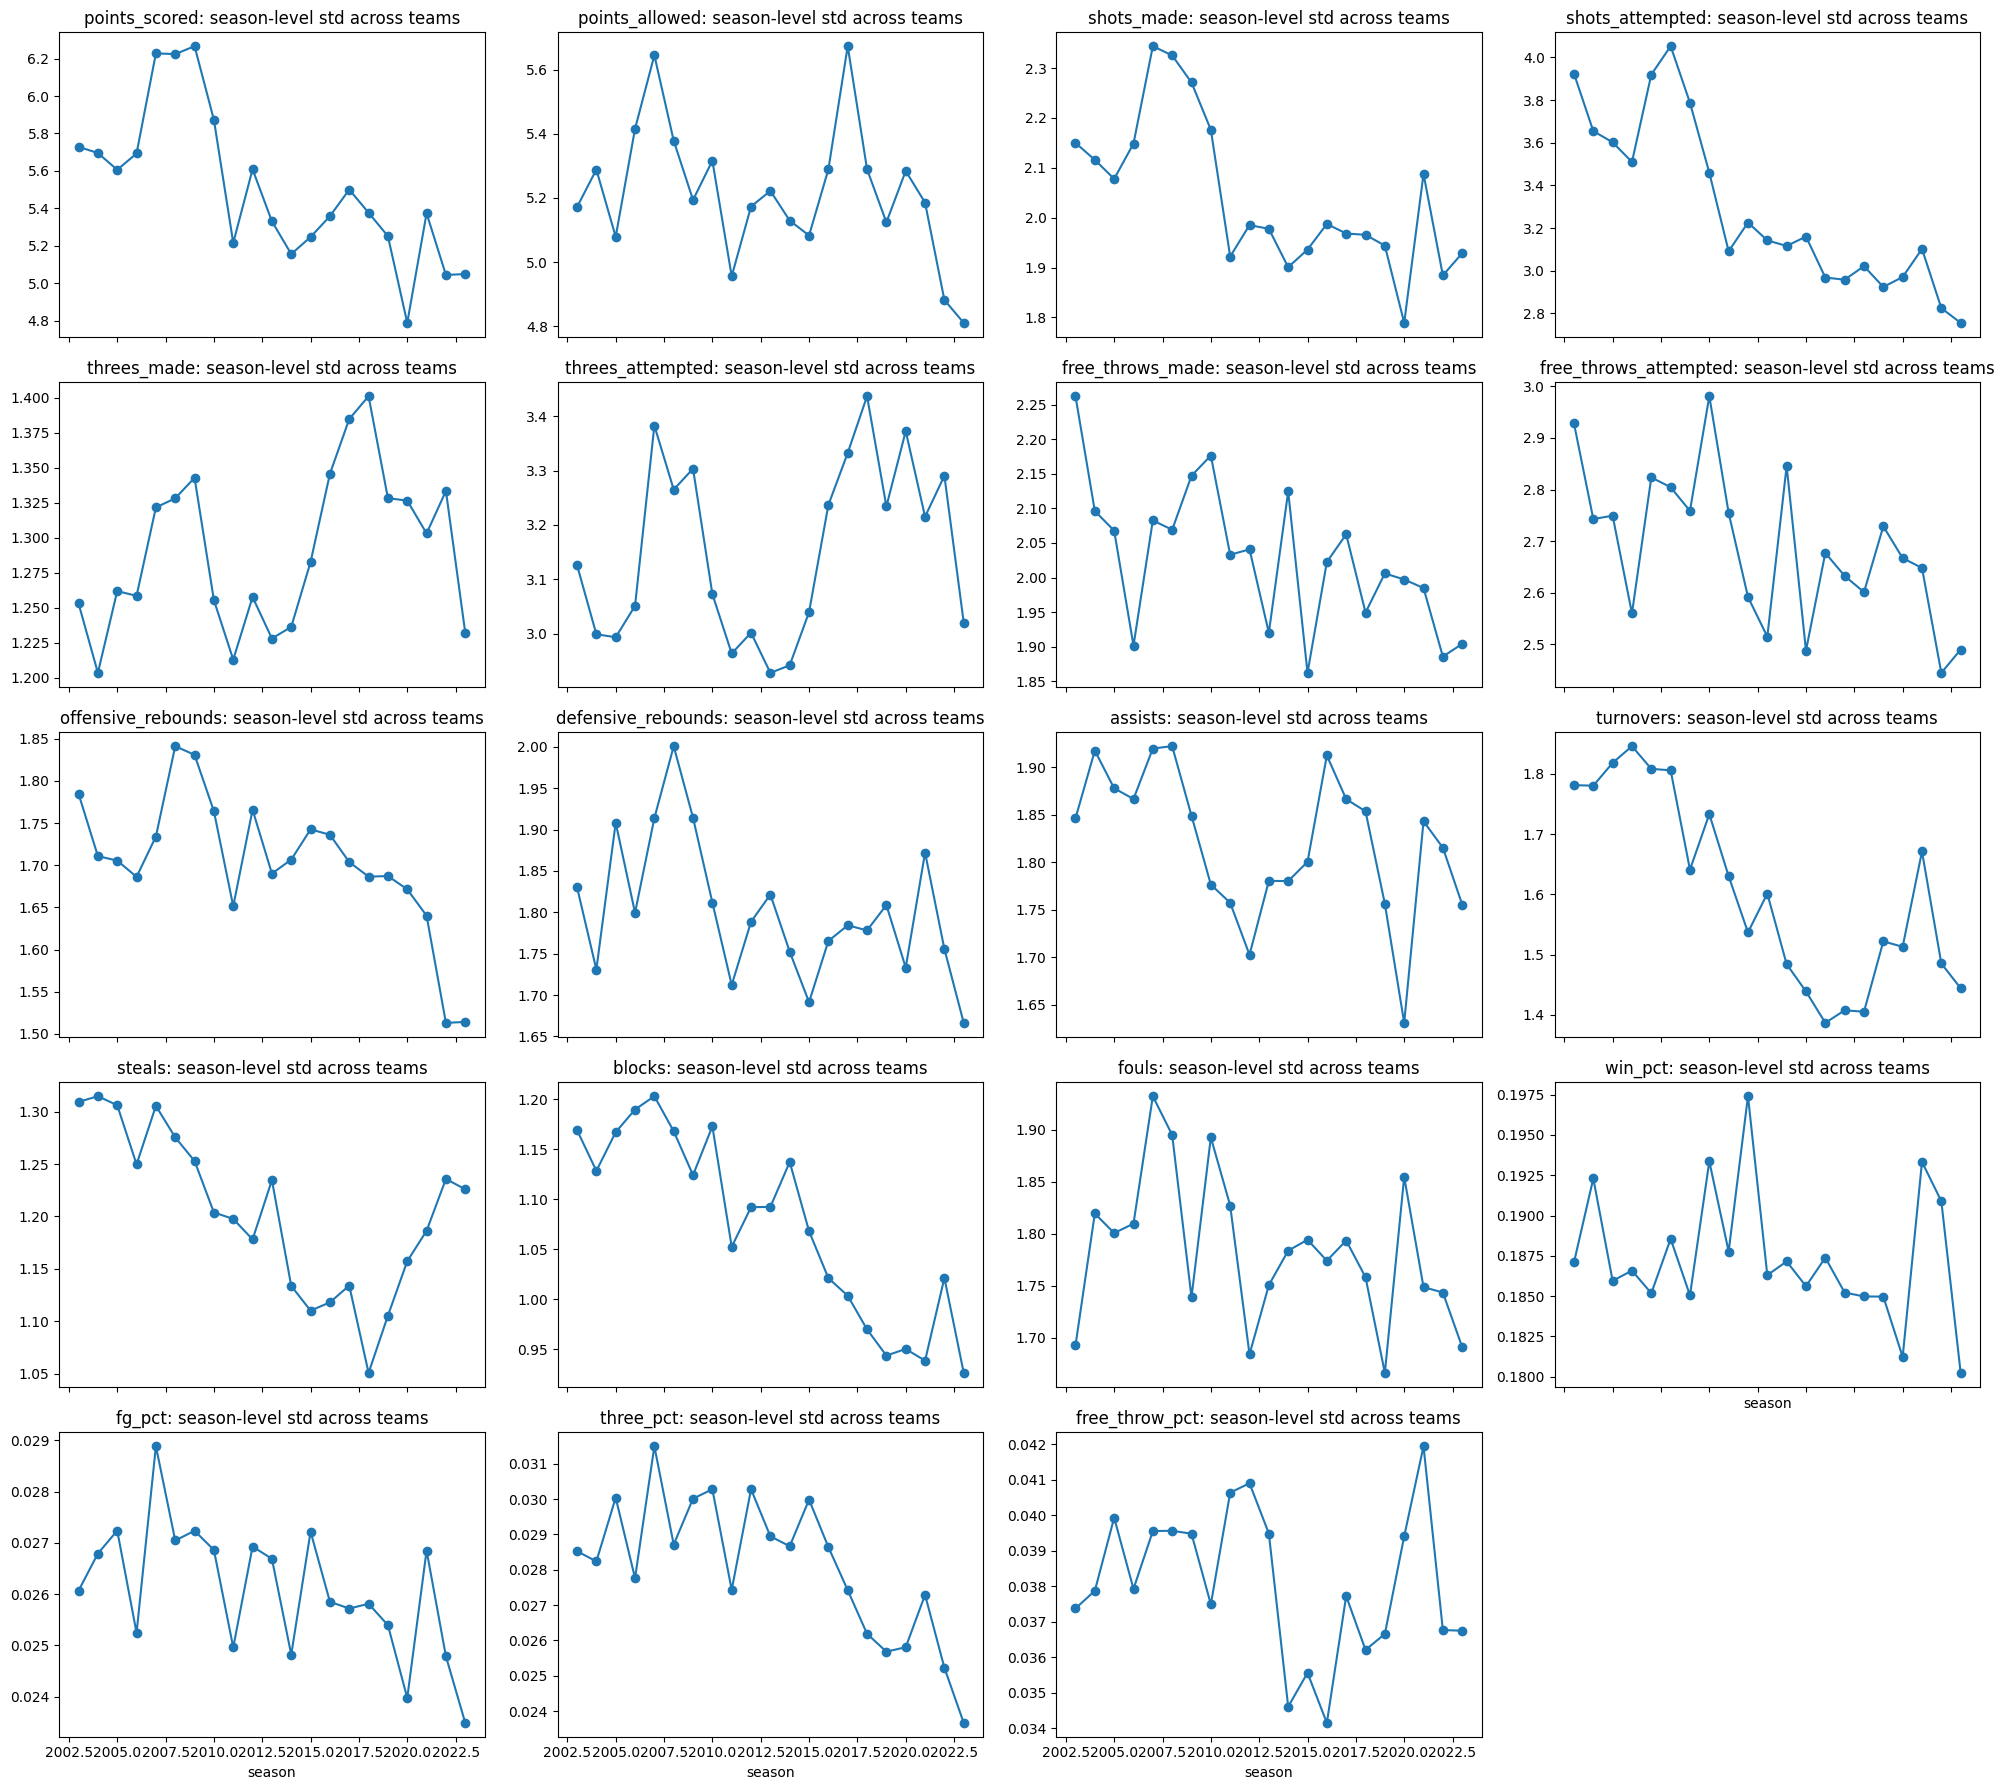

In [17]:
season_std_trend = train_stats.groupby('season')[stat_cols].std()

fig, axes = plt.subplots(5, 4, figsize=(20, 18), sharex=True)
axes = axes.flatten()

for i, stat in enumerate(stat_cols):
    axes[i].plot(season_std_trend.index, season_std_trend[stat], marker='o')
    axes[i].set_title(f'{stat}: season-level std across teams')
    if i >= 15:
        axes[i].set_xlabel('season')
        
for j in range(len(stat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
std_summary = season_std_trend.agg(['mean', 'std']).T
std_summary['coefficient_of_variation'] = std_summary['std'] / std_summary['mean']
std_summary.sort_values('coefficient_of_variation', ascending=False)

,mean,std,coefficient_of_variation
shots_attempted,3.293791,0.394008,0.119621
turnovers,1.606717,0.157873,0.098258
blocks,1.073357,0.092391,0.086076
shots_made,2.042128,0.150388,0.073643
points_scored,5.506015,0.402676,0.073134
three_pct,0.028109,0.001979,0.070408
steals,1.204014,0.076995,0.063949
free_throw_pct,0.038101,0.002084,0.054696
free_throws_attempted,2.687289,0.145676,0.054209
threes_attempted,3.152660,0.163682,0.051919


While we see the expected stats towards the top of the coefficient of variation sort, the magnitude is insignificant, meaning the stat spread has been essentially stable over the period of interest, which is a reasonable conclusion given our total data range is 20 years and league wide drift exists on a smaller scale compared to if we were looking at the full era of college basketball.

## Upset Rate
Predicting upsets is the core of performing well in tournament predictions, especially given how well engineered the seed is as a feature. Here we simply seek to develop some intuition for how often upsets actually occur.

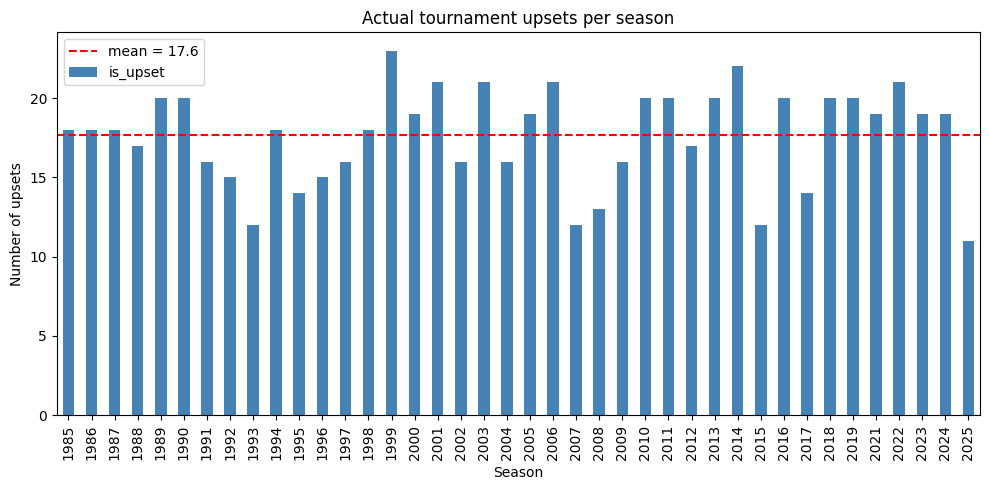

In [19]:
import matplotlib.pyplot as plt

from src.data.ingest import load_raw_data
from src.simulation.bracket import build_seed_lookup
from src.utils.config import load_config

config = load_config('configs/baseline.yaml')
raw = load_raw_data(config['data']['raw_dir'])
tourney_results = raw['tourney_results']
seeds_raw = raw['seeds']

seed_lookup = build_seed_lookup(seeds_raw)

seed_w = tourney_results.apply(lambda r: seed_lookup.loc[(r['Season'], r['WTeamID'])], axis=1)
seed_l = tourney_results.apply(lambda r: seed_lookup.loc[(r['Season'], r['LTeamID'])], axis=1)

has_favorite = seed_w != seed_l
is_upset = seed_w > seed_l

upsets_per_season = (
    tourney_results[has_favorite]
    .assign(is_upset=is_upset[has_favorite])
    .groupby('Season')['is_upset']
    .sum()
)

ax = upsets_per_season.plot(kind='bar', figsize=(10, 5), color='steelblue')
ax.set_xlabel('Season')
ax.set_ylabel('Number of upsets')
ax.set_title('Actual tournament upsets per season')
ax.axhline(upsets_per_season.mean(), color='red', linestyle='--', label=f'mean = {upsets_per_season.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()